In [179]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [180]:
df = pd.read_csv("../../datasets/07_caravan_insurance/caravan-insurance-challenge.csv", sep=',')

In [181]:
df.head()

,ORIGIN,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,...,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND,CARAVAN
0,train,33,1,3,2,8,0,5,1,3,...,0,0,0,1,0,0,0,0,0,0
1,train,37,1,2,2,8,1,4,1,4,...,0,0,0,1,0,0,0,0,0,0
2,train,37,1,2,2,8,0,4,2,4,...,0,0,0,1,0,0,0,0,0,0
3,train,9,1,3,3,3,2,3,2,4,...,0,0,0,1,0,0,0,0,0,0
4,train,40,1,4,2,10,1,4,1,4,...,0,0,0,1,0,0,0,0,0,0


In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9822 entries, 0 to 9821
Data columns (total 87 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ORIGIN    9822 non-null   object
 1   MOSTYPE   9822 non-null   int64 
 2   MAANTHUI  9822 non-null   int64 
 3   MGEMOMV   9822 non-null   int64 
 4   MGEMLEEF  9822 non-null   int64 
 5   MOSHOOFD  9822 non-null   int64 
 6   MGODRK    9822 non-null   int64 
 7   MGODPR    9822 non-null   int64 
 8   MGODOV    9822 non-null   int64 
 9   MGODGE    9822 non-null   int64 
 10  MRELGE    9822 non-null   int64 
 11  MRELSA    9822 non-null   int64 
 12  MRELOV    9822 non-null   int64 
 13  MFALLEEN  9822 non-null   int64 
 14  MFGEKIND  9822 non-null   int64 
 15  MFWEKIND  9822 non-null   int64 
 16  MOPLHOOG  9822 non-null   int64 
 17  MOPLMIDD  9822 non-null   int64 
 18  MOPLLAAG  9822 non-null   int64 
 19  MBERHOOG  9822 non-null   int64 
 20  MBERZELF  9822 non-null   int64 
 21  MBERBOER  9822

In [183]:
train_data = df[df.iloc[:,0] == "train"]
test_data = df[df.iloc[:,0] == "test"]

X_train = train_data.iloc[:,1:-1]
y_train = train_data.iloc[:,-1]

X_test = test_data.iloc[:, 1:-1]
y_test = test_data.iloc[:, -1]

In [ ]:
# Using Random forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [185]:
for i in X_train.columns:
    print(i)
    print(X_train[i].unique())

MOSTYPE
[33 37  9 40 23 39 11 10 41 38 22 13 31 34 24  8  7  3 36 25 20 12 35 30
 29 32  1 26  2  4 16  5 21  6 18 27 28 17 15 19]
MAANTHUI
[ 1  2  3 10  5  7  4  8  6]
MGEMOMV
[3 2 4 1 5]
MGEMLEEF
[2 3 1 4 5 6]
MOSHOOFD
[ 8  3 10  5  9  7  2  1  6  4]
MGODRK
[0 1 2 3 4 6 5 9 7 8]
MGODPR
[5 4 3 2 7 1 6 9 0 8]
MGODOV
[1 2 0 3 4 5]
MGODGE
[3 4 5 2 6 7 0 1 9 8]
MRELGE
[7 6 3 5 0 1 9 8 2 4]
MRELSA
[0 2 1 6 4 3 5 7]
MRELOV
[2 4 3 0 1 6 5 7 8 9]
MFALLEEN
[1 0 4 2 3 5 6 7 8 9]
MFGEKIND
[2 4 3 5 6 0 1 7 8 9]
MFWEKIND
[6 5 2 4 3 1 7 9 8 0]
MOPLHOOG
[1 0 3 5 4 2 6 7 8 9]
MOPLMIDD
[2 5 4 3 1 7 6 0 8 9]
MOPLLAAG
[7 4 2 0 5 6 8 3 1 9]
MBERHOOG
[1 0 4 2 3 6 5 7 9 8]
MBERZELF
[0 5 1 2 3 4]
MBERBOER
[1 0 4 3 2 5 6 7 8 9]
MBERMIDD
[2 5 7 3 0 4 1 9 6 8]
MBERARBG
[5 0 1 2 8 3 4 6 7 9]
MBERARBO
[2 4 0 5 1 3 7 6 9 8]
MSKA
[1 0 3 9 2 4 5 6 7 8]
MSKB1
[1 2 5 0 3 4 8 6 9 7]
MSKB2
[2 3 0 1 4 6 5 7 8 9]
MSKC
[6 5 4 0 8 1 2 7 3 9]
MSKD
[1 0 2 5 3 4 7 6 9]
MHHUUR
[1 2 7 5 4 9 6 0 8 3]
MHKOOP
[8 7 2 4 5 0 3 9 1 6]

In [186]:
# to check which column is important
importance = model.feature_importances_
sorted_indices = np.argsort(importance)[::-1] # np.argsort() returns indices

feature_names = X_train.columns.to_list()

for i in sorted_indices:
    print(f"{feature_names[i]}: {importance[i]}")

PBRAND: 0.053319995218614455
PPERSAUT: 0.042788136948625925
APERSAUT: 0.041729472271430916
MOSTYPE: 0.038176304567009774
PWAPART: 0.02757370621230977
MKOOPKLA: 0.024043099574895498
ABRAND: 0.02367531626344719
AWAPART: 0.021732694256330464
MOSHOOFD: 0.020978843447203896
MOPLMIDD: 0.019127429509409998
MFWEKIND: 0.01882639954837407
MBERMIDD: 0.01832726299085635
MOPLLAAG: 0.018158152261724854
MHKOOP: 0.01801446071253325
MFGEKIND: 0.017946399416170235
MINK3045: 0.017722570554313522
MOPLHOOG: 0.0171452226904647
MGODGE: 0.01704180728082969
MSKC: 0.016946307041151444
MBERARBG: 0.016359655723953214
MBERARBO: 0.016314239963700284
MGODPR: 0.016281348674574297
MINK4575: 0.015895084741883142
MSKA: 0.015850142081638537
MHHUUR: 0.01574827967949259
MSKB2: 0.015587843764186647
MINKM30: 0.015296985444765633
MAUT1: 0.015119676760158381
MBERHOOG: 0.01490354328931308
MZPART: 0.014593102153716371
MRELGE: 0.014565836886895505
MFALLEEN: 0.014437098513017676
MINKGEM: 0.014262503592452225
MGODOV: 0.014260667223

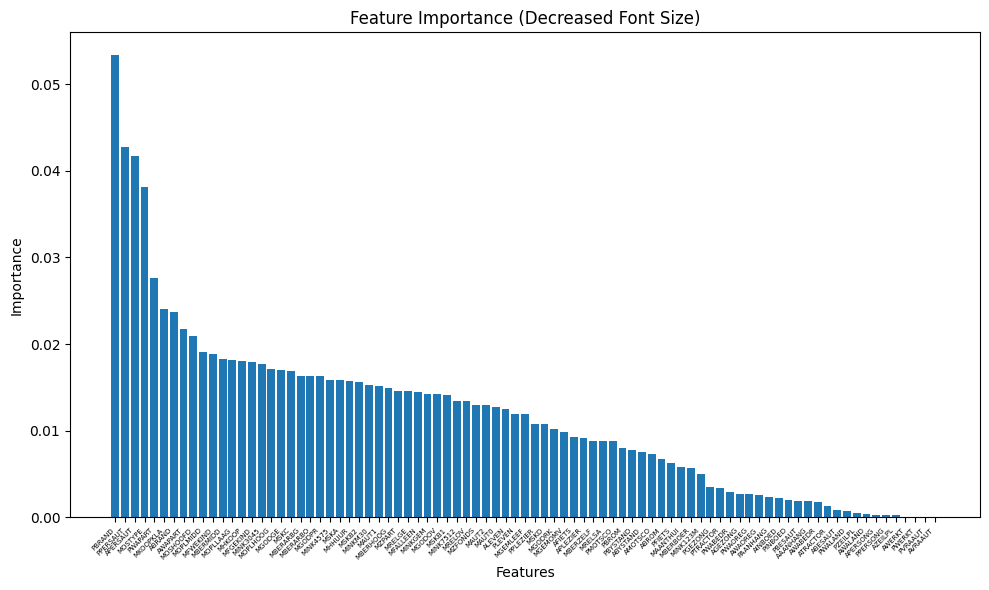

In [187]:
fig, ax = plt.subplots(figsize=(10,6))
ax.bar([feature_names[i] for i in sorted_indices], importance[sorted_indices])
ax.set_xlabel("Features")
ax.set_ylabel("Importance")
ax.set_title('Feature Importance')
ax.tick_params(axis='x', rotation=45)
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels([feature_names[i] for i in sorted_indices], rotation=45, ha='right')
ax.set_title('Feature Importance (Decreased Font Size)')
ax.tick_params(axis='x', labelsize=5)
plt.tight_layout()
plt.show()

In [188]:
# Evaluation
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {accuracy:.0f}%")

Accuracy: 93%


In [189]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      3762
           1       0.21      0.06      0.09       238

    accuracy                           0.93      4000
   macro avg       0.58      0.52      0.53      4000
weighted avg       0.90      0.93      0.91      4000



The results show that the data is highly imbalanced.

In [190]:
# logistic regression
from sklearn.linear_model import LogisticRegression
model_logistic = LogisticRegression()
model_logistic.fit(X_train, y_train)

y_pred_log = model.predict(X_test)

c:\Users\vishn\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


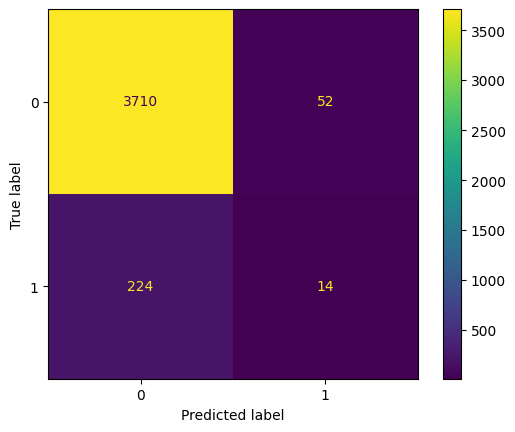

In [191]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [192]:
from sklearn.metrics import roc_curve, roc_auc_score

prob = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, prob)

print(auc)

0.6778834340753845


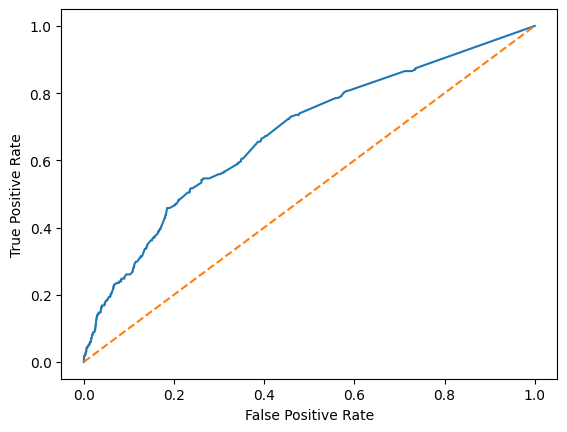

In [193]:
fpr, tpr, _ = roc_curve(y_test, prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [194]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.9914118859498454
0.931
